# OD Connectivity Analysis: School Accessibility and Commuting

This notebook evaluates the **demand-relevant connectivity** of the West Midlands
directed LTS network for two trip purposes central to the LTN 1/20 "cycling for
all" principle

1. **School accessibility** (Part A) using OSM-derived school locations and LSOA
   centroids, we test how many children can reach their nearest school via a
   low-stress route, weighted by LSOA population.
2. **Commuting connectivity** (Part B) using Census 2011 MSOA-level OD commuting
   flows (preferred over 2021 data collected during COVID-19 lockdown), we test
   what proportion of short-distance commuting trips can be completed within each
   LTS-constrained network.

Both analyses employ **directed Dijkstra shortest-path routing** on LTS-filtered
subgraphs with 30 m gap bridging (consistent with notebook 05). Tolerance analysis
routes on the next higher LTS subgraph and applies 5% / 10% detour thresholds
relative to the unconstrained baseline.

**Fast-path support.** On first run the gap-bridged subgraphs are cached to pickle.
Subsequent runs load the cache in seconds. Set `FORCE_RECOMPUTE = True` to rebuild.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import dijkstra
from scipy.spatial import cKDTree
from shapely.geometry import Point, LineString
from shapely import STRtree

DATA_DIR = Path('../Data/Raw')
CLEANED_DIR = Path('../Data/Cleaned')
OUTPUT_DIR = Path('../Data/Cleaned')
FIG_DIR = Path('../Figures')
FIG_DIR.mkdir(exist_ok=True)

CRS_BNG = 'EPSG:27700'
GAP_CLOSE_M = 30  # consistent with notebook 05

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

LTS_COLORS = {
    1: '#2ca02c',
    2: '#f0c929',
    3: '#e8601c',
    4: '#d62728',
}

STUDY_AREA_BOROUGHS = [
    'Birmingham', 'Coventry', 'Dudley', 'Sandwell',
    'Solihull', 'Walsall', 'Wolverhampton',
]

## 1. Data Loading

### 1.1 Study Area

In [2]:
raw_data = gpd.read_file(
    DATA_DIR / "Local_Authority_Districts_DEC_2025_Boundaries_UK_BFC_7781342770234899863/LAD_DEC_2025_UK_BFC.shp"
)
study_area = raw_data[raw_data['LAD25NM'].isin(STUDY_AREA_BOROUGHS)].copy()
study_area = study_area.to_crs(CRS_BNG)
study_area_union = study_area.unary_union

print(f"Study area: {len(STUDY_AREA_BOROUGHS)} boroughs, "
      f"{study_area.geometry.area.sum()/1e6:.1f} km²")

Study area: 7 boroughs, 901.7 km²


### 1.2 Directed LTS Network

In [3]:
edges = gpd.read_file(OUTPUT_DIR / "network_lts_with_junctions.gpkg")
edges = edges.to_crs(CRS_BNG)
edges['osid'] = edges['edge_id'].str.rsplit('_', n=1).str[0]

print(f"Directed edges: {len(edges):,}")
print(f"LTS distribution:")
print(edges['lts_final'].value_counts().sort_index())

Directed edges: 480,228
LTS distribution:
lts_final
1.0    227420
2.0    152180
3.0     46464
4.0     54164
Name: count, dtype: int64


### 1.3 Network Graph Construction and Gap Bridging

**Cache control.** Set `FORCE_RECOMPUTE = False` (default) to load pre-computed
gap-bridged subgraphs from pickle. Set to `True` to rebuild from the edges
GeoDataFrame. The cache stores `G_full`, `lts_subgraphs` (with gap bridges
already added in-place), and `node_coords`.

In [4]:
FORCE_RECOMPUTE = False

SUBGRAPH_PKL = OUTPUT_DIR / 'lts_subgraphs_gapbridged.pkl'
COORDS_PKL   = OUTPUT_DIR / 'node_coords.pkl'
GFULL_PKL    = OUTPUT_DIR / 'G_full.pkl'

In [5]:
# ----- Helper functions -----

def build_directed_graph(edges_gdf):
    """Build a directed NetworkX graph from the edges GeoDataFrame.
    
    Handles backward edges explicitly: since geometry is NOT reversed
    in Notebook 00's edge expansion, coords[0] is always the startnode
    and coords[-1] is always the endnode regardless of edge direction.
    """
    G = nx.DiGraph()
    node_coords = {}
    for _, row in edges_gdf.iterrows():
        u, v = row['from_node'], row['to_node']
        geom = row['geometry']
        G.add_edge(u, v,
                   length=row['geometry_length_m'],
                   lts=row['lts_final'],
                   facility_type=row['facility_type'],
                   edge_id=row['edge_id'],
                   osid=row['osid'])
        coords = list(geom.coords)
        # Backward edges share the same (unreversed) geometry,
        # so determine start/end from edge_dir, not from coord order.
        if row.get('edge_dir', 'forward') == 'forward':
            start_coord, end_coord = coords[0][:2], coords[-1][:2]
        else:
            start_coord, end_coord = coords[-1][:2], coords[0][:2]
        node_coords.setdefault(u, start_coord)
        node_coords.setdefault(v, end_coord)
    nx.set_node_attributes(G, {n: {'x': c[0], 'y': c[1]}
                               for n, c in node_coords.items()})
    return G, node_coords


def extract_lts_subgraph(G, max_lts):
    """Extract a directed subgraph containing only edges with lts <= max_lts."""
    edge_list = [(u, v, d) for u, v, d in G.edges(data=True)
                 if d['lts'] <= max_lts]
    H = nx.DiGraph()
    H.add_edges_from(edge_list)
    for n in H.nodes():
        if n in G.nodes:
            H.nodes[n].update(G.nodes[n])
    return H


def close_gaps_directed(G, node_coords, max_gap_m, lts_level):
    """Bridge gaps <= max_gap_m between different weakly connected components.
    
    Adds bidirectional edges with facility_type='gap_bridge' and
    lts=lts_level. Only bridges across different components.
    """
    nodes_in_graph = [n for n in G.nodes() if n in node_coords]
    if len(nodes_in_graph) < 2:
        return 0
    node_list = list(nodes_in_graph)
    coords_array = np.array([node_coords[n] for n in node_list])
    tree = cKDTree(coords_array)
    pairs = tree.query_pairs(r=max_gap_m)

    comp_map = {}
    for comp_id, comp in enumerate(nx.weakly_connected_components(G)):
        for n in comp:
            comp_map[n] = comp_id

    gaps_closed = 0
    for i, j in pairs:
        u, v = node_list[i], node_list[j]
        if comp_map.get(u) == comp_map.get(v):
            continue
        if G.has_edge(u, v) and G.has_edge(v, u):
            continue
        dist = np.linalg.norm(coords_array[i] - coords_array[j])
        if not G.has_edge(u, v):
            G.add_edge(u, v, length=dist, lts=lts_level,
                       facility_type='gap_bridge',
                       edge_id=f'gap_{u}_{v}', osid=f'gap_{u}_{v}')
        if not G.has_edge(v, u):
            G.add_edge(v, u, length=dist, lts=lts_level,
                       facility_type='gap_bridge',
                       edge_id=f'gap_{v}_{u}', osid=f'gap_{u}_{v}')
        gaps_closed += 1
        old_comp, new_comp = comp_map[v], comp_map[u]
        for n in list(comp_map.keys()):
            if comp_map[n] == old_comp:
                comp_map[n] = new_comp
    return gaps_closed

In [7]:
import pickle

if not FORCE_RECOMPUTE and SUBGRAPH_PKL.exists():
    # ===== FAST PATH: load cached gap-bridged subgraphs =====
    print("Loading cached gap-bridged subgraphs...")
    with open(SUBGRAPH_PKL, 'rb') as f:
        lts_subgraphs = pickle.load(f)
    with open(COORDS_PKL, 'rb') as f:
        node_coords = pickle.load(f)

    # G_full may not exist if cached by the old notebook
    if GFULL_PKL.exists():
        with open(GFULL_PKL, 'rb') as f:
            G_full = pickle.load(f)
        print("  G_full loaded from cache.")
    else:
        print("  G_full.pkl not found — rebuilding from edges (one-time)...")
        G_full, node_coords = build_directed_graph(edges)
        with open(GFULL_PKL, 'wb') as f:
            pickle.dump(G_full, f)
        print("  G_full saved to cache.")

    for lts in [1, 2, 3, 4]:
        H = lts_subgraphs[lts]
        n_gaps = sum(1 for _, _, d in H.edges(data=True)
                     if d.get('facility_type') == 'gap_bridge')
        total_km = sum(d['length'] for _, _, d in H.edges(data=True)) / 1000
        print(f"  LTS <= {lts}: {H.number_of_nodes():>7,} nodes, "
              f"{H.number_of_edges():>7,} edges, {total_km:>8,.1f} km "
              f"({n_gaps:,} gap bridges)")
    print(f"  G_full: {G_full.number_of_nodes():,} nodes, "
          f"{G_full.number_of_edges():,} edges")
    print("Done.")

else:
    # ===== SLOW PATH: build everything from scratch =====
    print("Building directed graph from edges GeoDataFrame...")
    G_full, node_coords = build_directed_graph(edges)
    print(f"G_full: {G_full.number_of_nodes():,} nodes, "
          f"{G_full.number_of_edges():,} edges")

    lts_subgraphs = {}
    for lts_level in [1, 2, 3, 4]:
        H = extract_lts_subgraph(G_full, lts_level)
        lts_subgraphs[lts_level] = H
        total_km = sum(d['length'] for _, _, d in H.edges(data=True)) / 1000
        print(f"  LTS <= {lts_level}: {H.number_of_nodes():>7,} nodes, "
              f"{H.number_of_edges():>7,} edges, {total_km:>8,.1f} km")

    print(f"\nGap closing (max {GAP_CLOSE_M} m):")
    print("-" * 65)
    for lts_level in [1, 2, 3, 4]:
        H = lts_subgraphs[lts_level]
        n_before = nx.number_weakly_connected_components(H)
        n_gaps = close_gaps_directed(H, node_coords, GAP_CLOSE_M, lts_level)
        n_after = nx.number_weakly_connected_components(H)
        print(f"  LTS <= {lts_level}: {n_gaps:>5,} gaps closed | "
              f"Components: {n_before:>6,} -> {n_after:>6,} "
              f"({n_before - n_after:>5,} merged)")

    with open(SUBGRAPH_PKL, 'wb') as f:
        pickle.dump(lts_subgraphs, f)
    with open(COORDS_PKL, 'wb') as f:
        pickle.dump(node_coords, f)
    with open(GFULL_PKL, 'wb') as f:
        pickle.dump(G_full, f)
    print("\nSaved to cache.")

Loading cached gap-bridged subgraphs...
  G_full.pkl not found — rebuilding from edges (one-time)...
  G_full saved to cache.
  LTS <= 1: 191,802 nodes, 290,801 edges, 11,037.1 km (63,892 gap bridges)
  LTS <= 2: 222,327 nodes, 430,932 edges, 18,824.7 km (53,712 gap bridges)
  LTS <= 3: 239,161 nodes, 474,100 edges, 20,981.5 km (49,886 gap bridges)
  LTS <= 4: 253,548 nodes, 521,792 edges, 23,818.9 km (43,362 gap bridges)
  G_full: 253,548 nodes, 478,430 edges
Done.


### 1.4 Largest Weakly Connected Component and Node Snapping

In [8]:
components = sorted(nx.weakly_connected_components(G_full), key=len, reverse=True)
giant = components[0]

print(f"Total weakly connected components: {len(components)}")
print(f"LWCC: {len(giant):,} nodes ({len(giant)/G_full.number_of_nodes()*100:.1f}%)")

# Node lookup restricted to LWCC
nodes_data = []
for n in giant:
    if n in node_coords:
        nodes_data.append({'node_id': n, 'x': node_coords[n][0], 'y': node_coords[n][1]})
nodes_giant = pd.DataFrame(nodes_data)
nodes_giant_gdf = gpd.GeoDataFrame(
    nodes_giant, geometry=gpd.points_from_xy(nodes_giant.x, nodes_giant.y), crs=CRS_BNG
)
tree_giant = STRtree(nodes_giant_gdf.geometry.values)

def snap_to_giant(centroid):
    idx = tree_giant.nearest(centroid)
    return nodes_giant_gdf.iloc[idx]["node_id"]

print(f"Nodes available for snapping: {len(nodes_giant_gdf):,}")

Total weakly connected components: 21944
LWCC: 193,995 nodes (76.5%)
Nodes available for snapping: 193,995


### 1.5 Sparse Graph Construction

Build sparse adjacency matrices for `scipy.sparse.csgraph.dijkstra`. Gap bridge
edges are deduplicated: if the same `(u, v)` pair is bridged in multiple LTS
subgraphs, only the bridge with the lowest LTS value is kept (it will be included
in all higher-threshold graphs automatically).

In [9]:
# Node index mapping: all nodes from edges + gap bridge nodes
all_node_ids = set(edges['from_node']) | set(edges['to_node'])

for lts_level in [1, 2, 3, 4]:
    for u, v, d in lts_subgraphs[lts_level].edges(data=True):
        if d.get('facility_type') == 'gap_bridge':
            all_node_ids.update([u, v])

all_node_ids = list(all_node_ids)
node_to_idx = {nid: i for i, nid in enumerate(all_node_ids)}
n_nodes = len(node_to_idx)

# Base edges from GeoDataFrame
all_src = edges['from_node'].map(node_to_idx).values.tolist()
all_dst = edges['to_node'].map(node_to_idx).values.tolist()
all_len = edges['geometry_length_m'].values.astype(float).tolist()
all_lts = edges['lts_final'].values.tolist()

# Gap bridges: deduplicate — keep lowest LTS per (u, v)
gap_edges = {}  # (u_idx, v_idx) -> (length, lts)
for lts_level in [1, 2, 3, 4]:
    for u, v, d in lts_subgraphs[lts_level].edges(data=True):
        if d.get('facility_type') == 'gap_bridge':
            key = (node_to_idx[u], node_to_idx[v])
            if key not in gap_edges or d['lts'] < gap_edges[key][1]:
                gap_edges[key] = (d['length'], d['lts'])

for (ui, vi), (length, lts) in gap_edges.items():
    all_src.append(ui)
    all_dst.append(vi)
    all_len.append(length)
    all_lts.append(lts)

all_src = np.array(all_src)
all_dst = np.array(all_dst)
all_len = np.array(all_len, dtype=float)
all_lts = np.array(all_lts)


def build_strict_graph(lts_threshold):
    mask = all_lts <= lts_threshold
    return csr_matrix(
        (all_len[mask], (all_src[mask], all_dst[mask])),
        shape=(n_nodes, n_nodes)
    )


print(f"Node index size: {n_nodes:,}")
print(f"Base edges: {len(edges):,}")
print(f"Gap bridges (deduplicated): {len(gap_edges):,}")
print(f"Total edges in sparse arrays: {len(all_src):,}")

Node index size: 253,548
Base edges: 480,228
Gap bridges (deduplicated): 146,732
Total edges in sparse arrays: 626,960



## Part A -- School Accessibility

### 2. Data Preparation

#### 2.1 LSOA Boundaries and Population

In [10]:
lsoa_uk = gpd.read_file(
    DATA_DIR / "Lower_layer_Super_Output_Areas_December_2021_Boundaries_EW_BGC_V5_-3761339731474027792.geojson"
)
lsoa_uk = lsoa_uk.to_crs(CRS_BNG)

lsoa_uk['centroid'] = lsoa_uk.geometry.centroid
lsoa_uk_centroids = lsoa_uk.set_geometry('centroid')
lsoa_wm = gpd.sjoin(lsoa_uk_centroids, study_area[["LAD25NM", "geometry"]], predicate="within")
lsoa_wm = lsoa_wm.set_geometry("geometry").drop(columns=["centroid", "index_right"])

# Join LSOA population (Census 2021 TS001)
lsoa_pop = pd.read_csv(DATA_DIR / 'census2021-ts001/census2021-ts001-lsoa.csv')
lsoa_pop = lsoa_pop.rename(columns={
    'geography code': 'LSOA21CD',
    'Residence type: Total; measures: Value': 'population'
})
lsoa_wm = lsoa_wm.merge(lsoa_pop[['LSOA21CD', 'population']], on='LSOA21CD', how='left')

# Snap LSOA centroids to LWCC
lsoa_wm_cents = lsoa_wm.copy().set_geometry(lsoa_wm.geometry.centroid)
lsoa_wm_cents["snapped_node"] = lsoa_wm_cents.geometry.apply(snap_to_giant)
lsoa_to_node = dict(zip(lsoa_wm_cents["LSOA21CD"], lsoa_wm_cents["snapped_node"]))

print(f"WM LSOAs: {len(lsoa_wm):,}")
print(f"Total population: {lsoa_wm['population'].sum():,.0f}")
print(f"Snapped to LWCC: {len(lsoa_to_node):,}")

WM LSOAs: 1,718
Total population: 2,917,976
Snapped to LWCC: 1,718


#### 2.2 School Locations

In [11]:
import pyrosm

pbf_path = DATA_DIR / "west-midlands-260504.osm.pbf"
osm = pyrosm.OSM(str(pbf_path))
pois = osm.get_pois(custom_filter={"amenity": ["school"]})
pois = pois.to_crs(CRS_BNG)
pois["geometry"] = pois.geometry.centroid

schools_wm = gpd.sjoin(pois, study_area[["LAD25NM", "geometry"]], predicate="within")
schools_wm = schools_wm.drop(columns=["index_right"]).reset_index(drop=True)

print(f"Schools in West Midlands: {len(schools_wm)}")
print(f"By borough:")
print(schools_wm.groupby("LAD25NM").size().sort_values(ascending=False))

# Snap schools to LWCC
schools_wm["snapped_node"] = schools_wm.geometry.apply(snap_to_giant)
school_node_indices = np.array([
    node_to_idx[n] for n in schools_wm["snapped_node"].unique()
    if n in node_to_idx
])
print(f"\nSchool nodes (unique, in LWCC): {len(school_node_indices)}")

Schools in West Midlands: 1220
By borough:
LAD25NM
Birmingham       484
Sandwell         149
Coventry         139
Walsall          128
Dudley           121
Wolverhampton    110
Solihull          89
dtype: int64

School nodes (unique, in LWCC): 1199


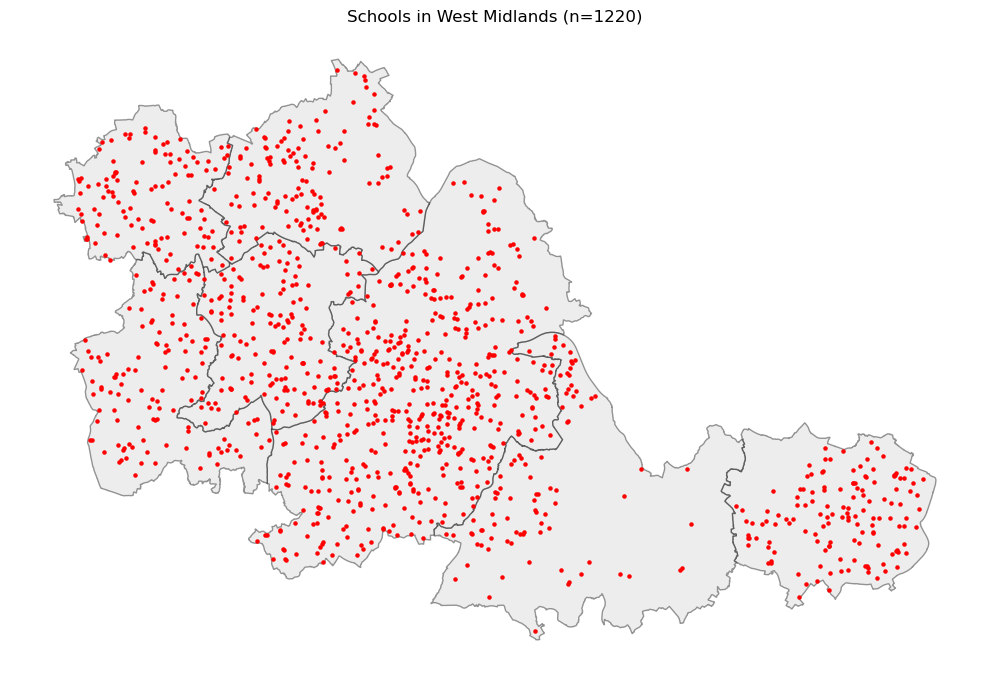

In [12]:
# Map of schools
fig, ax = plt.subplots(figsize=(10, 10))
study_area.plot(ax=ax, facecolor="lightgrey", edgecolor="black", alpha=0.4)
schools_wm.plot(ax=ax, color="red", markersize=5, zorder=3)
ax.set_title(f"Schools in West Midlands (n={len(schools_wm)})")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(FIG_DIR / "schools_map.png", dpi=200, bbox_inches="tight")
plt.show()

### 3. School Accessibility Computation

### School Accessibility Computation

School accessibility uses reversed-graph Dijkstra, routing from each school 
node outward on the transposed adjacency matrix to obtain the shortest distance 
to that school from every node. For each LSOA, the minimum across all schools 
gives the nearest-school distance.

Two routing modes are tested. The strict mode routes directly on each LTS 
subgraph (1, 2, 3, 4). The tolerance mode routes on the next higher LTS 
subgraph and accepts the result if distance is within 5 or 10 percent of 
the unconstrained baseline.


In [13]:
def compute_school_accessibility(graph, school_indices, lsoa_to_node, node_to_idx):
    graph_T = graph.T.tocsr()
    dist_matrix = dijkstra(graph_T, directed=True, indices=school_indices)
    results = {}
    for lsoa_code, node_id in lsoa_to_node.items():
        if node_id not in node_to_idx:
            continue
        node_idx = node_to_idx[node_id]
        min_dist = dist_matrix[:, node_idx].min()
        results[lsoa_code] = min_dist if np.isfinite(min_dist) else np.nan
    return results

# Strict LTS routing
school_results = {}
for lts in [1, 2, 3, 4]:
    print(f"Computing school accessibility: LTS ≤ {lts}...")
    graph = build_strict_graph(lts)
    dists = compute_school_accessibility(graph, school_node_indices, lsoa_to_node, node_to_idx)
    school_results[lts] = dists
    reachable = sum(1 for d in dists.values() if np.isfinite(d))
    print(f"  Reachable: {reachable}/{len(dists)} ({reachable/len(dists)*100:.1f}%)")

# Unconstrained baseline (= LTS ≤ 4)
baseline_school = school_results[4]

Computing school accessibility: LTS ≤ 1...
  Reachable: 73/1718 (4.2%)
Computing school accessibility: LTS ≤ 2...
  Reachable: 1122/1718 (65.3%)
Computing school accessibility: LTS ≤ 3...
  Reachable: 1467/1718 (85.4%)
Computing school accessibility: LTS ≤ 4...
  Reachable: 1717/1718 (99.9%)


In [14]:
# Tolerance: route on LTS ≤ (target+1), filter by detour ratio
TOLERANCES = [0.05, 0.10]

school_tol_results = {}
for target_lts in [1, 2]:
    next_lts = target_lts + 1
    print(f"\nTolerance for LTS ≤ {target_lts} (routing on LTS ≤ {next_lts}):")
    graph_next = build_strict_graph(next_lts)
    dists_next = compute_school_accessibility(graph_next, school_node_indices, lsoa_to_node, node_to_idx)

    for tol in TOLERANCES:
        filtered = {}
        for lsoa, d_next in dists_next.items():
            d_unc = baseline_school.get(lsoa, np.nan)
            if np.isfinite(d_next) and np.isfinite(d_unc) and d_unc > 0:
                if d_next <= (1 + tol) * d_unc:
                    filtered[lsoa] = d_next
                else:
                    filtered[lsoa] = np.nan
            else:
                filtered[lsoa] = np.nan
        school_tol_results[(target_lts, tol)] = filtered
        reachable = sum(1 for d in filtered.values() if np.isfinite(d))
        print(f"  {int(tol*100)}% tolerance: {reachable}/{len(filtered)} LSOAs reachable")


Tolerance for LTS ≤ 1 (routing on LTS ≤ 2):
  5% tolerance: 554/1718 LSOAs reachable
  10% tolerance: 594/1718 LSOAs reachable

Tolerance for LTS ≤ 2 (routing on LTS ≤ 3):
  5% tolerance: 912/1718 LSOAs reachable
  10% tolerance: 962/1718 LSOAs reachable


### 4. School Accessibility Results

#### 4.1 Summary Table (Population-Weighted)

In [15]:
# Build summary with population weighting
lsoa_pop_dict = dict(zip(lsoa_wm['LSOA21CD'], lsoa_wm['population']))
total_pop = sum(lsoa_pop_dict.get(l, 0) for l in lsoa_to_node.keys())

print("=" * 85)
print("School Accessibility Summary (nearest school, directed routing)")
print("=" * 85)
print(f"{'Scenario':<30}  {'LSOAs':>7}  {'% LSOAs':>8}  {'Pop':>10}  {'% Pop':>7}")
print("-" * 85)

n_lsoas = len(lsoa_to_node)

# Strict
for lts in [1, 2, 3, 4]:
    dists = school_results[lts]
    reachable_lsoas = [l for l, d in dists.items() if np.isfinite(d)]
    n_reach = len(reachable_lsoas)
    pop_reach = sum(lsoa_pop_dict.get(l, 0) for l in reachable_lsoas)
    label = f"LTS ≤ {lts}, strict"
    print(f"{label:<30}  {n_reach:>7,}  {n_reach/n_lsoas*100:>7.1f}%  "
          f"{pop_reach:>10,}  {pop_reach/total_pop*100:>6.1f}%")

# Tolerance
for target_lts in [1, 2]:
    for tol in TOLERANCES:
        dists = school_tol_results[(target_lts, tol)]
        reachable_lsoas = [l for l, d in dists.items() if np.isfinite(d)]
        n_reach = len(reachable_lsoas)
        pop_reach = sum(lsoa_pop_dict.get(l, 0) for l in reachable_lsoas)
        label = f"LTS ≤ {target_lts}, {int(tol*100)}% tol (via ≤{target_lts+1})"
        print(f"{label:<30}  {n_reach:>7,}  {n_reach/n_lsoas*100:>7.1f}%  "
              f"{pop_reach:>10,}  {pop_reach/total_pop*100:>6.1f}%")

School Accessibility Summary (nearest school, directed routing)
Scenario                          LSOAs   % LSOAs         Pop    % Pop
-------------------------------------------------------------------------------------
LTS ≤ 1, strict                      73      4.2%     120,941     4.1%
LTS ≤ 2, strict                   1,122     65.3%   1,905,002    65.3%
LTS ≤ 3, strict                   1,467     85.4%   2,490,650    85.4%
LTS ≤ 4, strict                   1,717     99.9%   2,915,106    99.9%
LTS ≤ 1, 5% tol (via ≤2)            554     32.2%     928,132    31.8%
LTS ≤ 1, 10% tol (via ≤2)           594     34.6%     995,713    34.1%
LTS ≤ 2, 5% tol (via ≤3)            912     53.1%   1,543,598    52.9%
LTS ≤ 2, 10% tol (via ≤3)           962     56.0%   1,628,857    55.8%


#### 4.2 Cumulative Accessibility Curves (Strict)

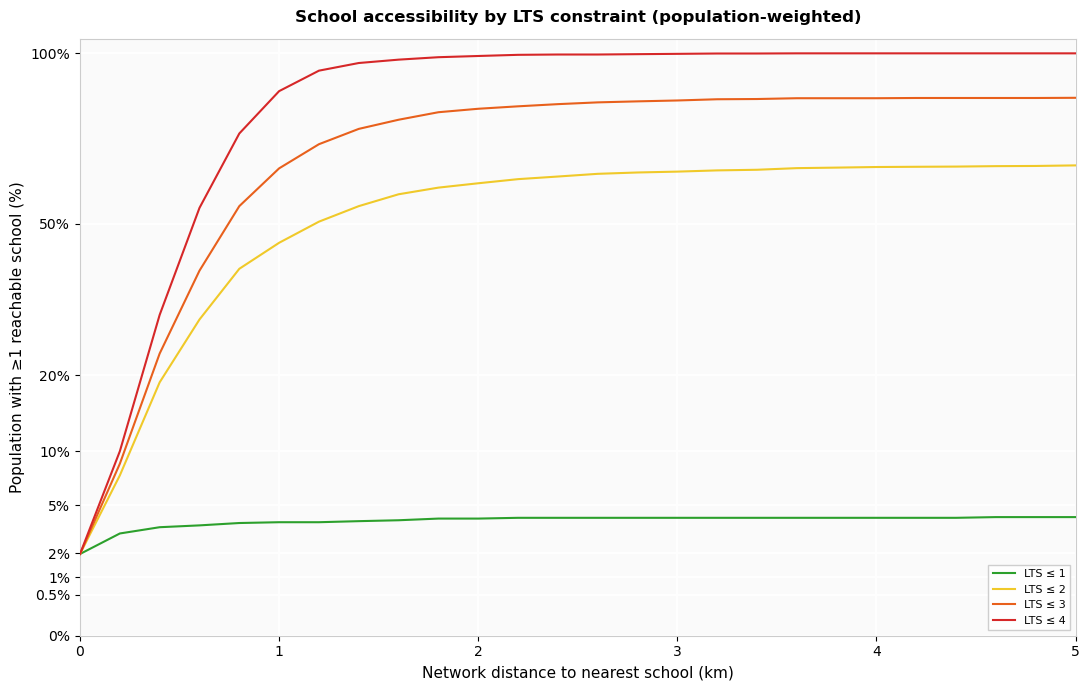

In [16]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("#fafafa")
ax.grid(True, color="white", linewidth=1.2, zorder=0)
ax.set_axisbelow(True)

thresholds_m = np.arange(0, 10001, 200)

for lts in [1, 2, 3, 4]:
    dists = school_results[lts]
    dist_values = np.array([dists.get(lsoa, np.nan) for lsoa in lsoa_to_node.keys()])
    pop_values = np.array([lsoa_pop_dict.get(lsoa, 0) for lsoa in lsoa_to_node.keys()])

    # Population-weighted cumulative curve
    cum_pct = []
    for d in thresholds_m:
        mask = dist_values <= d
        cum_pct.append(np.where(np.isnan(dist_values), 0, mask).dot(pop_values) / total_pop * 100)
    ax.plot(thresholds_m / 1000, cum_pct,
            color=LTS_COLORS[lts], linewidth=1.5, label=f"LTS ≤ {lts}", zorder=3)

ax.set_yscale("function",
              functions=(lambda x: np.sqrt(x), lambda x: x**2))
ax.set_ylim(0, 105)
ax.set_xlim(0, 5)
ax.set_yticks([0, 0.5, 1, 2, 5, 10, 20, 50, 100])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:g}%"))
ax.set_xlabel("Network distance to nearest school (km)", fontsize=11)
ax.set_ylabel("Population with ≥1 reachable school (%)", fontsize=11)
ax.set_title("School accessibility by LTS constraint (population-weighted)",
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc="lower right", fontsize=8, frameon=True,
          fancybox=False, edgecolor="#cccccc", framealpha=0.95)
for spine in ax.spines.values():
    spine.set_color("#cccccc")
plt.tight_layout()
plt.savefig(FIG_DIR / "school_accessibility_by_lts_popweighted.png", dpi=300, bbox_inches="tight")
plt.show()

#### 4.3 School Accessibility with Tolerance

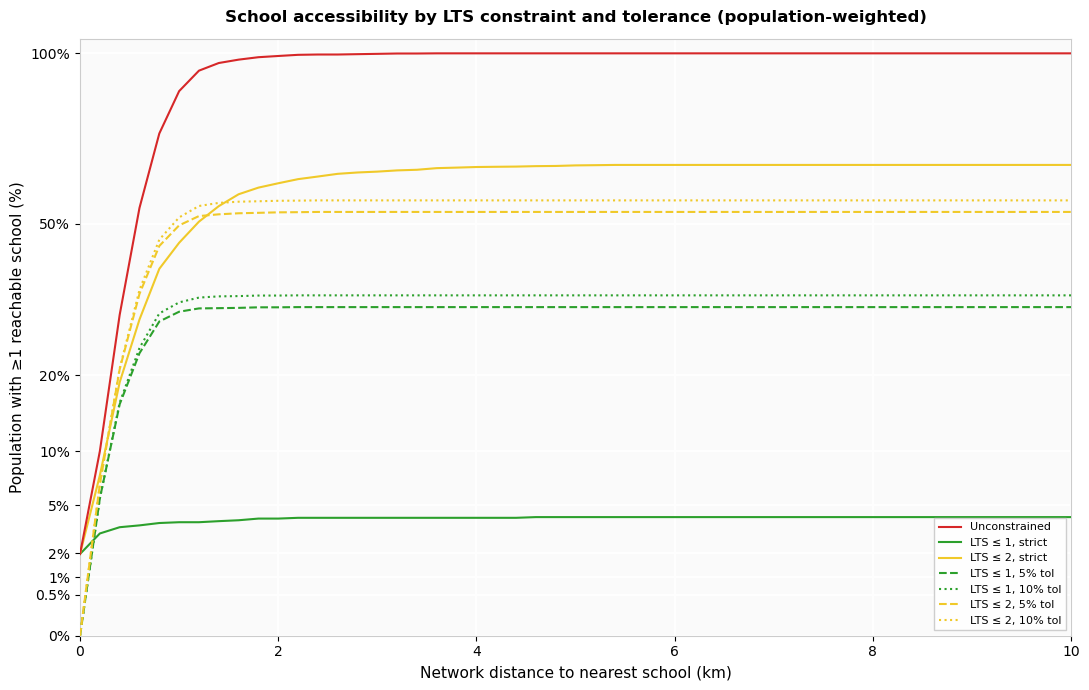

In [17]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("#fafafa")
ax.grid(True, color="white", linewidth=1.2, zorder=0)
ax.set_axisbelow(True)

thresholds_m = np.arange(0, 10001, 200)
TOL_STYLES = {0.05: "--", 0.10: ":"}

# Unconstrained baseline
dists_unc = school_results[4]
dist_vals_unc = np.array([dists_unc.get(l, np.nan) for l in lsoa_to_node.keys()])
pop_vals = np.array([lsoa_pop_dict.get(l, 0) for l in lsoa_to_node.keys()])
cum_base = [np.where(np.isnan(dist_vals_unc), 0, dist_vals_unc <= d).dot(pop_vals) / total_pop * 100
            for d in thresholds_m]
ax.plot(thresholds_m / 1000, cum_base,
        color=LTS_COLORS[4], linewidth=1.5, label="Unconstrained", zorder=4)

# Strict for reference
for lts in [1, 2]:
    dists = school_results[lts]
    dist_vals = np.array([dists.get(l, np.nan) for l in lsoa_to_node.keys()])
    cum_pct = [np.where(np.isnan(dist_vals), 0, dist_vals <= d).dot(pop_vals) / total_pop * 100
               for d in thresholds_m]
    ax.plot(thresholds_m / 1000, cum_pct,
            color=LTS_COLORS[lts], linestyle='-', linewidth=1.5, label=f"LTS ≤ {lts}, strict", zorder=3)

# Tolerance
for target_lts in [1, 2]:
    for tol in TOLERANCES:
        dists = school_tol_results[(target_lts, tol)]
        dist_vals = np.array([dists.get(l, np.nan) for l in lsoa_to_node.keys()])
        cum_pct = [np.where(np.isnan(dist_vals), 0, dist_vals <= d).dot(pop_vals) / total_pop * 100
                   for d in thresholds_m]
        ax.plot(thresholds_m / 1000, cum_pct,
                color=LTS_COLORS[target_lts], linestyle=TOL_STYLES[tol],
                linewidth=1.5, zorder=3,
                label=f"LTS ≤ {target_lts}, {int(tol*100)}% tol")

ax.set_yscale("function",
              functions=(lambda x: np.sqrt(x), lambda x: x**2))
ax.set_ylim(0, 105)
ax.set_xlim(0, 10)
ax.set_yticks([0, 0.5, 1, 2, 5, 10, 20, 50, 100])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:g}%"))
ax.set_xlabel("Network distance to nearest school (km)", fontsize=11)
ax.set_ylabel("Population with ≥1 reachable school (%)", fontsize=11)
ax.set_title("School accessibility by LTS constraint and tolerance (population-weighted)",
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc="lower right", fontsize=8, frameon=True,
          fancybox=False, edgecolor="#cccccc", framealpha=0.95)
for spine in ax.spines.values():
    spine.set_color("#cccccc")
plt.tight_layout()
plt.savefig(FIG_DIR / "school_accessibility_tolerance_popweighted.png", dpi=300, bbox_inches="tight")
plt.show()


## Part B -- Commuting Connectivity

### 5. Census 2011 OD Data

In [18]:
# Load MSOA boundaries
msoa = gpd.read_file(
    DATA_DIR / "Middle_Layer_Super_Output_Areas_Dec_2001_Boundaries_EW_BGC_2022_1570857564621828750.geojson"
)
msoa = msoa.to_crs(CRS_BNG)
msoa["centroid"] = msoa.geometry.centroid
msoa_centroids = msoa.set_geometry("centroid")
msoa_wm = gpd.sjoin(msoa_centroids, study_area[["LAD25NM", "geometry"]], predicate="within")
msoa_wm = msoa_wm.set_geometry("geometry").drop(columns=["centroid", "index_right"])

msoa_code_col = "MSOA21CD" if "MSOA21CD" in msoa_wm.columns else "MSOA01CD"
print(f"WM MSOAs: {len(msoa_wm)}")

WM MSOAs: 356


In [19]:
# Load and filter Census 2011 OD data
census_2011 = pd.read_csv(DATA_DIR / "census_2011/ODWP03EW_MSOA.csv")
print(f"Raw data: {len(census_2011):,} rows")

census_2011["MSOA of workplace code"] = census_2011["MSOA of workplace code"].astype(str).str.strip()
census_2011["Middle layer Super Output Areas code"] = census_2011["Middle layer Super Output Areas code"].astype(str).str.strip()

census_2011 = census_2011[~census_2011["MSOA of workplace code"].isin({"-8", "999999999"})].copy()
census_2011["Place of work indicator (4 categories) code"] = pd.to_numeric(
    census_2011["Place of work indicator (4 categories) code"], errors="coerce"
)
census_2011 = census_2011[census_2011["Place of work indicator (4 categories) code"] == 3].copy()
print(f"After filtering to commuters (code=3): {len(census_2011):,} rows")

census_2011["Count"] = pd.to_numeric(census_2011["Count"], errors="coerce").fillna(0).astype(int)
od = (
    census_2011.groupby(
        ["Middle layer Super Output Areas code", "Middle layer Super Output Areas label",
         "MSOA of workplace code", "MSOA of workplace label"],
        as_index=False,
    )["Count"].sum()
)
od.columns = ["o_msoa", "o_name", "d_msoa", "d_name", "flow"]
print(f"After aggregation: {len(od):,} OD pairs, total flow = {od['flow'].sum():,}")

# Filter to WM internal trips
wm_msoas = set(msoa_wm[msoa_code_col])
od_wm = od[od["o_msoa"].isin(wm_msoas) & od["d_msoa"].isin(wm_msoas)].copy()
od_wm = od_wm[od_wm["flow"] > 0]
print(f"\nWM internal OD pairs: {len(od_wm):,}, total flow = {od_wm['flow'].sum():,}")

# Exclude intra-MSOA trips
intra = od_wm[od_wm["o_msoa"] == od_wm["d_msoa"]]
print(f"Intra-MSOA pairs: {len(intra):,} ({intra['flow'].sum()/od_wm['flow'].sum()*100:.1f}% of flow)")
od_wm = od_wm[od_wm["o_msoa"] != od_wm["d_msoa"]].copy()
total_inter_flow = od_wm["flow"].sum()
print(f"Inter-MSOA OD pairs: {len(od_wm):,}, flow = {total_inter_flow:,}")

# Filter to ≤ 8 km straight-line distance
msoa_cent_dict = dict(zip(msoa_wm[msoa_code_col], msoa_wm.geometry.centroid))
od_wm["sl_dist_m"] = od_wm.apply(
    lambda r: msoa_cent_dict[r["o_msoa"]].distance(msoa_cent_dict[r["d_msoa"]])
    if r["o_msoa"] in msoa_cent_dict and r["d_msoa"] in msoa_cent_dict else np.nan,
    axis=1
)
od_wm_8km = od_wm[od_wm["sl_dist_m"] <= 8000].copy()
total_8km_flow = od_wm_8km["flow"].sum()
print(f"\nOD pairs ≤ 8 km: {len(od_wm_8km):,}, flow = {total_8km_flow:,} "
      f"({total_8km_flow/total_inter_flow*100:.1f}% of inter-MSOA flow)")

Raw data: 2,587,993 rows
After filtering to commuters (code=3): 2,538,509 rows
After aggregation: 1,829,955 OD pairs, total flow = 15,094,155

WM internal OD pairs: 56,664, total flow = 540,011
Intra-MSOA pairs: 340 (6.2% of flow)
Inter-MSOA OD pairs: 56,324, flow = 506,372

OD pairs ≤ 8 km: 19,770, flow = 370,221 (73.1% of inter-MSOA flow)


### 5.1 Snap MSOA Centroids to Network

In [20]:
msoa_codes = set(od_wm_8km["o_msoa"]) | set(od_wm_8km["d_msoa"])
msoa_cents = msoa_wm[msoa_wm[msoa_code_col].isin(msoa_codes)].copy()
msoa_cents = msoa_cents.set_geometry(msoa_cents.geometry.centroid)
msoa_cents["snapped_node"] = msoa_cents.geometry.apply(snap_to_giant)
msoa_to_node = dict(zip(msoa_cents[msoa_code_col], msoa_cents["snapped_node"]))

print(f"Snapped {len(msoa_to_node)} MSOA centroids to LWCC nodes")

Snapped 340 MSOA centroids to LWCC nodes


### 6. Commuting OD Routing

In [21]:
def compute_od_distances(graph, msoa_to_node, node_to_idx, od_df):
    origin_msoas = od_df["o_msoa"].unique()
    origin_nodes = [msoa_to_node[m] for m in origin_msoas if m in msoa_to_node]
    origin_indices = np.array([node_to_idx[n] for n in origin_nodes if n in node_to_idx])

    dist_matrix = dijkstra(graph, directed=True, indices=origin_indices)

    origin_to_row = {}
    row_idx = 0
    for m in origin_msoas:
        if m in msoa_to_node and msoa_to_node[m] in node_to_idx:
            origin_to_row[m] = row_idx
            row_idx += 1

    result = od_df.copy()
    o_rows = result["o_msoa"].map(origin_to_row)
    d_cols = result["d_msoa"].map(msoa_to_node).map(node_to_idx)

    distances = np.full(len(result), np.nan)
    valid = o_rows.notna() & d_cols.notna()
    if valid.any():
        r = o_rows[valid].astype(int).values
        c = d_cols[valid].astype(int).values
        d = dist_matrix[r, c]
        d[d == np.inf] = np.nan
        distances[valid.values] = d
    result["distance_m"] = distances
    return result

In [22]:
commute_results = {}

# Unconstrained baseline
print("Computing unconstrained baseline (LTS ≤ 4)...")
graph_unc = build_strict_graph(4)
res_unc = compute_od_distances(graph_unc, msoa_to_node, node_to_idx, od_wm_8km)
commute_results["unconstrained"] = res_unc
conn = res_unc["distance_m"].notna().sum()
print(f"  Connected: {conn:,} / {len(res_unc):,} ({conn/len(res_unc)*100:.1f}%)")

# Strict routing: LTS ≤ 1, 2, 3
for lts in [1, 2, 3]:
    print(f"\nComputing strict LTS ≤ {lts}...")
    graph = build_strict_graph(lts)
    res = compute_od_distances(graph, msoa_to_node, node_to_idx, od_wm_8km)
    commute_results[(lts, "strict")] = res
    conn = res["distance_m"].notna().sum()
    print(f"  Connected: {conn:,} / {len(res):,} ({conn/len(res)*100:.1f}%)")

Computing unconstrained baseline (LTS ≤ 4)...
  Connected: 19,770 / 19,770 (100.0%)

Computing strict LTS ≤ 1...
  Connected: 1 / 19,770 (0.0%)

Computing strict LTS ≤ 2...
  Connected: 2,211 / 19,770 (11.2%)

Computing strict LTS ≤ 3...
  Connected: 10,334 / 19,770 (52.3%)


In [23]:
# Tolerance: route on LTS ≤ (target+1), filter by detour ratio
TOLERANCES = [0.05, 0.10]

for target_lts in [1, 2, 3]:
    next_lts = target_lts + 1
    print(f"\nTolerance for LTS ≤ {target_lts} (routing on LTS ≤ {next_lts}):")
    graph_next = build_strict_graph(next_lts)
    res_next = compute_od_distances(graph_next, msoa_to_node, node_to_idx, od_wm_8km)

    for tol in TOLERANCES:
        merged = res_next[["o_msoa", "d_msoa", "distance_m", "flow"]].merge(
            res_unc[["o_msoa", "d_msoa", "distance_m"]],
            on=["o_msoa", "d_msoa"], suffixes=("_next", "_unc")
        )
        valid = merged.dropna(subset=["distance_m_next", "distance_m_unc"]).copy()
        valid = valid[valid["distance_m_unc"] > 0]
        within = valid[valid["distance_m_next"] <= (1 + tol) * valid["distance_m_unc"]].copy()

        tol_result = within[["o_msoa", "d_msoa", "flow"]].copy()
        tol_result["distance_m"] = within["distance_m_next"].values
        commute_results[(target_lts, tol)] = tol_result

        flow_pct = tol_result["flow"].sum() / total_8km_flow * 100
        print(f"  {int(tol*100)}% tolerance: {len(tol_result):,} pairs, "
              f"{flow_pct:.1f}% of ≤8km commuting flow")


Tolerance for LTS ≤ 1 (routing on LTS ≤ 2):
  5% tolerance: 59 pairs, 0.6% of ≤8km commuting flow
  10% tolerance: 101 pairs, 0.9% of ≤8km commuting flow

Tolerance for LTS ≤ 2 (routing on LTS ≤ 3):
  5% tolerance: 399 pairs, 3.3% of ≤8km commuting flow
  10% tolerance: 760 pairs, 5.6% of ≤8km commuting flow

Tolerance for LTS ≤ 3 (routing on LTS ≤ 4):
  5% tolerance: 19,770 pairs, 100.0% of ≤8km commuting flow
  10% tolerance: 19,770 pairs, 100.0% of ≤8km commuting flow


### 7. Commuting Connectivity Results

#### 7.1 Summary Statistics

In [24]:
print("=" * 85)
print("Commuting OD Connectivity Summary (≤ 8 km straight-line)")
print("=" * 85)
print(f"Total OD pairs (≤ 8 km): {len(od_wm_8km):,}")
print(f"Total flow (≤ 8 km):     {total_8km_flow:,}")
print()
print(f"{'Scenario':<35}  {'Pairs':>8}  {'% Pairs':>8}  {'Flow':>10}  {'% Flow':>8}")
print("-" * 85)

# Unconstrained
unc = commute_results["unconstrained"]
unc_conn = unc.dropna(subset=["distance_m"])
print(f"{'Unconstrained (LTS ≤ 4)':<35}  {len(unc_conn):>8,}  "
      f"{len(unc_conn)/len(od_wm_8km)*100:>7.1f}%  "
      f"{unc_conn['flow'].sum():>10,}  "
      f"{unc_conn['flow'].sum()/total_8km_flow*100:>7.1f}%")

for lts in [1, 2, 3]:
    strict = commute_results[(lts, "strict")]
    s_conn = strict.dropna(subset=["distance_m"])
    print(f"{'LTS ≤ '+str(lts)+', strict':<35}  {len(s_conn):>8,}  "
          f"{len(s_conn)/len(od_wm_8km)*100:>7.1f}%  "
          f"{s_conn['flow'].sum():>10,}  "
          f"{s_conn['flow'].sum()/total_8km_flow*100:>7.1f}%")

for target_lts in [1, 2, 3]:
    for tol in TOLERANCES:
        key = (target_lts, tol)
        if key in commute_results:
            tol_res = commute_results[key]
            label = f"LTS ≤ {target_lts}, {int(tol*100)}% tol (via ≤{target_lts+1})"
            print(f"{label:<35}  {len(tol_res):>8,}  "
                  f"{len(tol_res)/len(od_wm_8km)*100:>7.1f}%  "
                  f"{tol_res['flow'].sum():>10,}  "
                  f"{tol_res['flow'].sum()/total_8km_flow*100:>7.1f}%")

Commuting OD Connectivity Summary (≤ 8 km straight-line)
Total OD pairs (≤ 8 km): 19,770
Total flow (≤ 8 km):     370,221

Scenario                                Pairs   % Pairs        Flow    % Flow
-------------------------------------------------------------------------------------
Unconstrained (LTS ≤ 4)                19,770    100.0%     370,221    100.0%
LTS ≤ 1, strict                             1      0.0%          21      0.0%
LTS ≤ 2, strict                         2,211     11.2%      48,198     13.0%
LTS ≤ 3, strict                        10,334     52.3%     186,339     50.3%
LTS ≤ 1, 5% tol (via ≤2)                   59      0.3%       2,054      0.6%
LTS ≤ 1, 10% tol (via ≤2)                 101      0.5%       3,362      0.9%
LTS ≤ 2, 5% tol (via ≤3)                  399      2.0%      12,306      3.3%
LTS ≤ 2, 10% tol (via ≤3)                 760      3.8%      20,886      5.6%
LTS ≤ 3, 5% tol (via ≤4)               19,770    100.0%     370,221    100.0%
LTS ≤ 3, 10

In [26]:
# Detour analysis for connected pairs
unc = commute_results["unconstrained"]

for lts in [1, 2, 3]:
    strict = commute_results[(lts, "strict")]
    merged = strict[["o_msoa", "d_msoa", "distance_m", "flow"]].merge(
        unc[["o_msoa", "d_msoa", "distance_m"]],
        on=["o_msoa", "d_msoa"],
        suffixes=("_lts", "_unc"),
    )
    valid = merged.dropna().copy()
    valid = valid[valid["distance_m_unc"] > 0]
    valid["detour_ratio"] = valid["distance_m_lts"] / valid["distance_m_unc"]
    
    print(f"\nLTS ≤ {lts} strict — detour ratio (connected pairs only):")
    print(f"  N pairs:  {len(valid):,}")
    print(f"  Median:   {valid['detour_ratio'].median():.2f}x")
    print(f"  Mean:     {valid['detour_ratio'].mean():.2f}x")
    print(f"  90th pct: {valid['detour_ratio'].quantile(0.9):.2f}x")
    print(f"  Flow-weighted mean: {np.average(valid['detour_ratio'], weights=valid['flow']):.2f}x")


LTS ≤ 1 strict — detour ratio (connected pairs only):
  N pairs:  1
  Median:   1.22x
  Mean:     1.22x
  90th pct: 1.22x
  Flow-weighted mean: 1.22x

LTS ≤ 2 strict — detour ratio (connected pairs only):
  N pairs:  2,211
  Median:   1.78x
  Mean:     2.21x
  90th pct: 3.63x
  Flow-weighted mean: 2.43x

LTS ≤ 3 strict — detour ratio (connected pairs only):
  N pairs:  10,334
  Median:   1.48x
  Mean:     1.73x
  90th pct: 2.58x
  Flow-weighted mean: 1.76x


#### 7.2 Cumulative Flow Curves

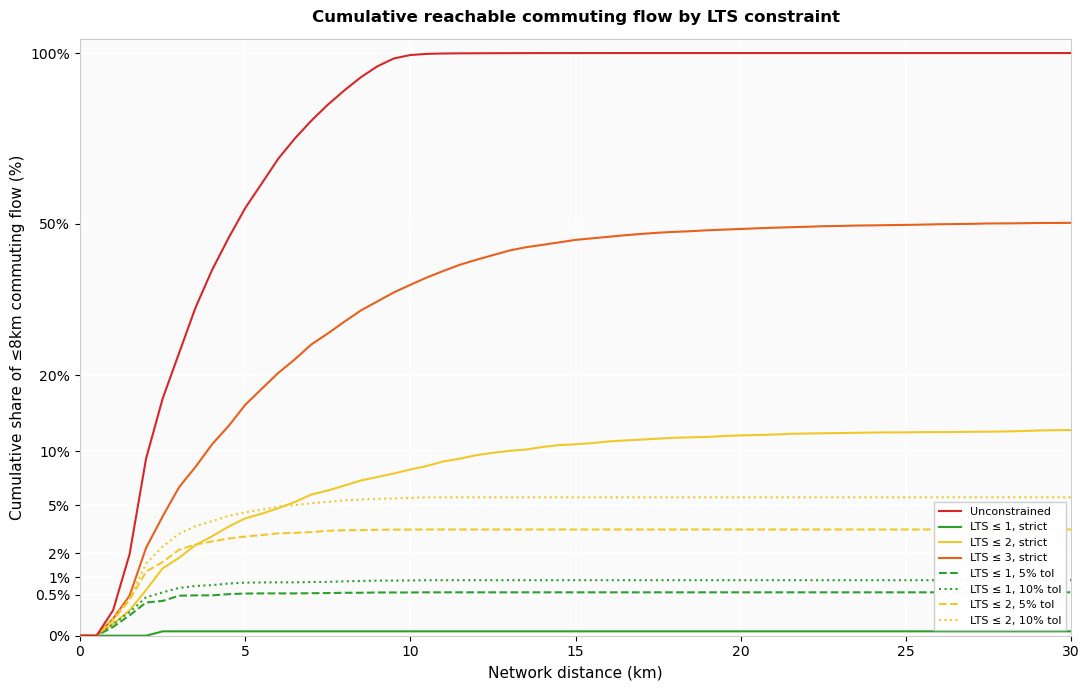

In [27]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#fafafa')
ax.grid(True, color='white', linewidth=1.2, zorder=0)
ax.set_axisbelow(True)

thresholds_m = np.arange(0, 30001, 500)
TOL_STYLES = {0.05: '--', 0.10: ':'}

# Unconstrained baseline
valid_unc = res_unc.dropna(subset=["distance_m"])
cum_base = [valid_unc[valid_unc["distance_m"] <= d]["flow"].sum() / total_8km_flow * 100
            for d in thresholds_m]
ax.plot(thresholds_m / 1000, cum_base,
        color=LTS_COLORS[4], linewidth=1.5, label="Unconstrained", zorder=4)

# Strict
for lts in [1, 2, 3]:
    strict = commute_results[(lts, "strict")]
    s_conn = strict.dropna(subset=["distance_m"])
    cum_pct = [s_conn[s_conn["distance_m"] <= d]["flow"].sum() / total_8km_flow * 100
               for d in thresholds_m]
    ax.plot(thresholds_m / 1000, cum_pct,
            color=LTS_COLORS[lts], linestyle='-', linewidth=1.5,
            label=f"LTS ≤ {lts}, strict", zorder=3)

# Tolerance
for target_lts in [1, 2]:
    for tol in TOLERANCES:
        key = (target_lts, tol)
        if key in commute_results:
            res = commute_results[key]
            cum_pct = [res[res["distance_m"] <= d]["flow"].sum() / total_8km_flow * 100
                       for d in thresholds_m]
            ax.plot(thresholds_m / 1000, cum_pct,
                    color=LTS_COLORS[target_lts], linestyle=TOL_STYLES[tol],
                    linewidth=1.5, zorder=3,
                    label=f"LTS ≤ {target_lts}, {int(tol*100)}% tol")

ax.set_yscale("function",
              functions=(lambda x: np.sqrt(x), lambda x: x**2))
ax.set_ylim(0, 105)
ax.set_xlim(0, 30)
ax.set_yticks([0, 0.5, 1, 2, 5, 10, 20, 50, 100])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:g}%"))
ax.set_xlabel("Network distance (km)", fontsize=11)
ax.set_ylabel("Cumulative share of ≤8km commuting flow (%)", fontsize=11)
ax.set_title("Cumulative reachable commuting flow by LTS constraint",
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='lower right', fontsize=8, frameon=True,
          fancybox=False, edgecolor='#cccccc', framealpha=0.95)
for spine in ax.spines.values():
    spine.set_color('#cccccc')
plt.tight_layout()
plt.savefig(FIG_DIR / "commuting_flow_by_lts.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Export

In [28]:
# Save commuting results
for key, res in commute_results.items():
    if isinstance(res, pd.DataFrame):
        label = str(key).replace(" ", "_").replace(",", "_").replace("(", "").replace(")", "").replace("'", "")
        res.to_csv(OUTPUT_DIR / f"commuting_od_{label}.csv", index=False)

# Save school accessibility as LSOA-level table
school_summary = pd.DataFrame({"LSOA21CD": list(lsoa_to_node.keys())})
for lts in [1, 2, 3, 4]:
    school_summary[f"school_dist_lts{lts}"] = school_summary["LSOA21CD"].map(school_results[lts])
for target_lts in [1, 2]:
    for tol in TOLERANCES:
        col = f"school_dist_lts{target_lts}_tol{int(tol*100)}"
        school_summary[col] = school_summary["LSOA21CD"].map(school_tol_results[(target_lts, tol)])
school_summary.to_csv(OUTPUT_DIR / "lsoa_school_accessibility.csv", index=False)

print("=" * 60)
print("EXPORT COMPLETE")
print("=" * 60)
print(f"Commuting OD results: {OUTPUT_DIR}/commuting_od_*.csv")
print(f"School accessibility:  {OUTPUT_DIR}/lsoa_school_accessibility.csv")

EXPORT COMPLETE
Commuting OD results: ../Data/Cleaned/commuting_od_*.csv
School accessibility:  ../Data/Cleaned/lsoa_school_accessibility.csv
